# T02 - Análisis de sensibilidad
##### Maria Fernanda Gómez Flores
##### Lunes 14 de Septiembre 2026

# Parte 1. Simulación de puts y calls

### Importar Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

/home/oai/.config/matplotlib is not a writable directory


## SIMULACIÓN

In [2]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 # cantidad de simulaciones
import numpy as np
import matplotlib.pyplot as plt
Z= np.random.normal(0,1,size=M)
ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
ST

array([ 90.25577513,  99.25163975, 128.60561335, ..., 100.54619307,
       125.77281238, 115.25084349], shape=(10000,))

## GANANCIAS PUT Y CALL

In [3]:
ganancia_put = np.maximum(K - ST, 0)
ganancia_call= np.maximum(ST - K, 0)

## PRECIO JUSTO POR SIMULACIÓN

### Put

In [4]:
precio_put_mc = np.exp(-r*T)*ganancia_put.mean()
precio_put_mc

np.float64(5.540676914518884)

### Call

In [5]:
precio_call_mc = np.exp(-r*T)*ganancia_call.mean()
precio_call_mc

np.float64(10.465897059691235)

## BLACK-SCHOLES

### Call

In [6]:
d1 = (np.log(S0 / K) + (r + (1/2) * V**2) * T) / (V * np.sqrt(T))
d2 = d1 - V * np.sqrt(T)
n1 = norm.cdf(d1)
n2 = norm.cdf(d2)
C = S0 * n1 - K * np.exp(-r * T) * n2
C

np.float64(10.450583572185565)

### Put

In [7]:
P = K * np.exp(-r*T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
P

np.float64(5.573526022256971)

## COMPARACIÓN

In [8]:
tabla = []

tabla.append(["Monte Carlo",precio_call_mc,precio_put_mc])
tabla.append(["Black-Scholes",C,P])

tabla = pd.DataFrame(tabla,columns=["Método","Call","Put"])

tabla

,Método,Call,Put
0,Monte Carlo,10.465897,5.540677
1,Black-Scholes,10.450584,5.573526


Los dos resultados salen muy parecidos pero no exactamente iguales porque en Monte Carlo estamos usando números aleatorios.

# Parte 2. Sensibilidad

## PRECIO DEL ACTIVO

### Put

In [9]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
precios = [80, 90, 100, 110, 120]

tabla = []

for S0 in precios:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)
    precio_put = np.exp(-r*T)*np.mean(ganancia_put)

    tabla.append([S0,precio_put])

tabla = pd.DataFrame(tabla,columns=["Precio del activo","Precio Put"])
tabla_put = tabla

tabla

,Precio del activo,Precio Put
0,80,17.114035
1,90,10.227468
2,100,5.528439
3,110,2.767448
4,120,1.253719


### Call

In [10]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
precios = [80, 90, 100, 110, 120]

tabla = []

for S0 in precios:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_call= np.maximum(ST - K, 0)
    precio_call = np.exp(-r*T)*np.mean(ganancia_call)

    tabla.append([S0,precio_call])

tabla = pd.DataFrame(tabla,columns=["Precio del activo","Precio Call"])
tabla_call = tabla

tabla

,Precio del activo,Precio Call
0,80,1.882948
1,90,5.094880
2,100,10.327343
3,110,17.651881
4,120,26.110157


### Gráfico

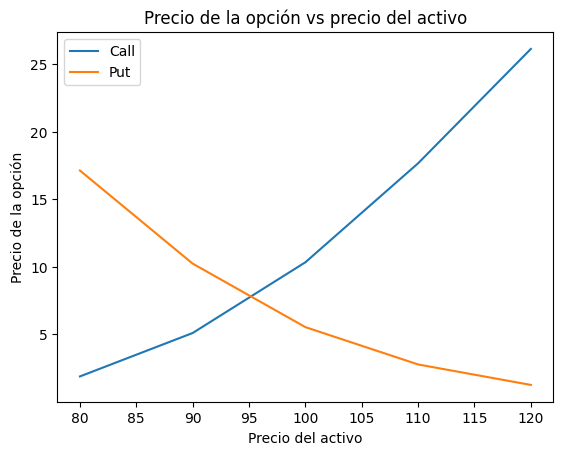

In [11]:
plt.plot(tabla_call["Precio del activo"], tabla_call["Precio Call"], label="Call")
plt.plot(tabla_put["Precio del activo"], tabla_put["Precio Put"], label="Put")

plt.xlabel("Precio del activo")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs precio del activo")
plt.legend()

plt.show()

La call aumenta porque entre mas sube el precio de la acción mas probable es que termine arriba de K y genere ganancia. En la put pasa lo contrario porque necesita que el precio termine abajo de K.

## PRECIO DE EJERCICIO

### Put

In [12]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
strikes = [80, 90, 100,110,120]

tabla = []

for K in strikes:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)
    precio_put = np.exp(-r*T)*np.mean(ganancia_put)

    tabla.append([K,precio_put])

tabla = pd.DataFrame(tabla,columns=["Precio de ejercicio K","Precio Put"])
tabla_put = tabla

tabla

,Precio de ejercicio K,Precio Put
0,80,0.706442
1,90,2.300106
2,100,5.604723
3,110,10.582273
4,120,17.232342


### Call

In [13]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
strikes = [80, 90, 100,110,120]

tabla = []

for K in strikes:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_call= np.maximum(ST - K, 0)
    precio_call = np.exp(-r*T)*np.mean(ganancia_call)

    tabla.append([K,precio_call])

tabla = pd.DataFrame(tabla,columns=["Precio de ejercicio K","Precio Call"])
tabla_call = tabla

tabla

,Precio de ejercicio K,Precio Call
0,80,24.322991
1,90,16.578665
2,100,10.420171
3,110,6.181566
4,120,3.353936


### Gráfico

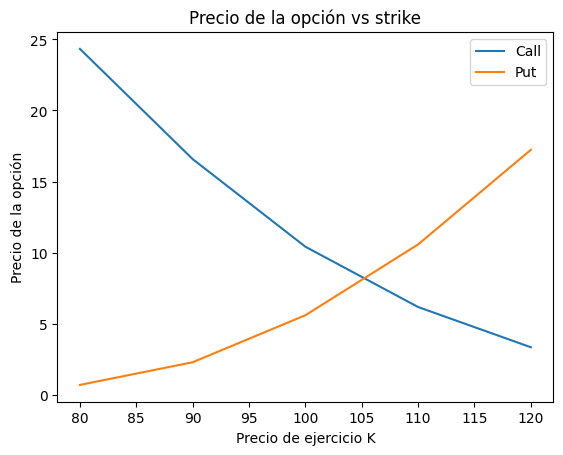

In [14]:
plt.plot(tabla_call["Precio de ejercicio K"], tabla_call["Precio Call"], label="Call")
plt.plot(tabla_put["Precio de ejercicio K"], tabla_put["Precio Put"], label="Put")

plt.xlabel("Precio de ejercicio K")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs strike")
plt.legend()

plt.show()

In-the-money significa que si ejerciera la opción en ese momento tendría valor. En una call es cuando ST > K y en una put cuando ST < K.

Si sube K es mas difícil para la call quedar in-the-money porque el precio tiene que subir mas. Para la put pasa lo contrario porque es mas fácil que el precio termine abajo de K.

## VOLATILIDAD

### Put

In [15]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]

tabla = []

for V in volatilidades:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)
    precio_put = np.exp(-r*T)*np.mean(ganancia_put)

    tabla.append([V,precio_put])

tabla = pd.DataFrame(tabla,columns=["Volatilidad","Precio Put"])
tabla_put = tabla

tabla

,Volatilidad,Precio Put
0,0.1,1.926499
1,0.2,5.560044
2,0.3,9.551209
3,0.4,13.032847
4,0.5,16.644551


### Call

In [16]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]

tabla = []

for V in volatilidades:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_call= np.maximum(ST - K, 0)
    precio_call = np.exp(-r*T)*np.mean(ganancia_call)

    tabla.append([V,precio_call])

tabla = pd.DataFrame(tabla,columns=["Volatilidad","Precio Call"])
tabla_call = tabla

tabla

,Volatilidad,Precio Call
0,0.1,6.807891
1,0.2,10.610657
2,0.3,14.237346
3,0.4,18.031319
4,0.5,21.506161


### Gráfico

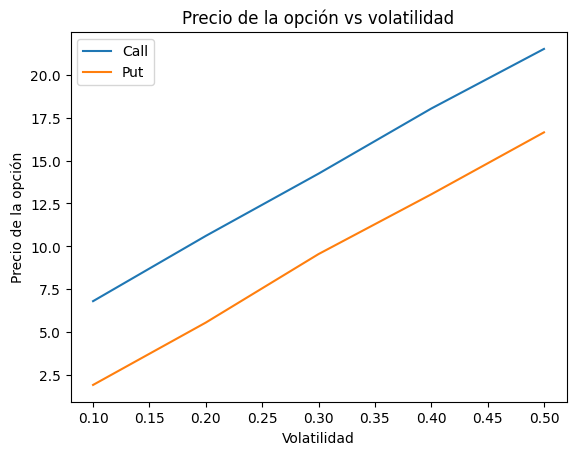

In [17]:
plt.plot(tabla_call["Volatilidad"], tabla_call["Precio Call"], label="Call")
plt.plot(tabla_put["Volatilidad"], tabla_put["Precio Put"], label="Put")

plt.xlabel("Volatilidad")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs volatilidad")
plt.legend()

plt.show()

Cuando aumenta la volatilidad aumentan las dos opciones porque hay mas posibilidad de que el precio se mueva mucho. Eso puede hacer que la call termine muy arriba de K o que la put termine muy abajo.

## TIEMPO

### Put

In [18]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tiempos = [0.25, 0.5, 1, 1.5, 2]

tabla = []

for T in tiempos:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)
    precio_put = np.exp(-r*T)*np.mean(ganancia_put)

    tabla.append([T,precio_put])

tabla = pd.DataFrame(tabla,columns=["Tiempo","Precio Put"])
tabla_put = tabla

tabla

,Tiempo,Precio Put
0,0.25,3.302971
1,0.50,4.376434
2,1.00,5.623795
3,1.50,6.198778
4,2.00,6.627962


### Call

In [19]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tiempos = [0.25, 0.5, 1, 1.5, 2]

tabla = []

for T in tiempos:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_call= np.maximum(ST - K, 0)
    precio_call = np.exp(-r*T)*np.mean(ganancia_call)

    tabla.append([T,precio_call])

tabla = pd.DataFrame(tabla,columns=["Tiempo","Precio Call"])
tabla_call = tabla

tabla

,Tiempo,Precio Call
0,0.25,4.532675
1,0.50,7.046746
2,1.00,10.603364
3,1.50,13.417829
4,2.00,16.430998


### Gráfico

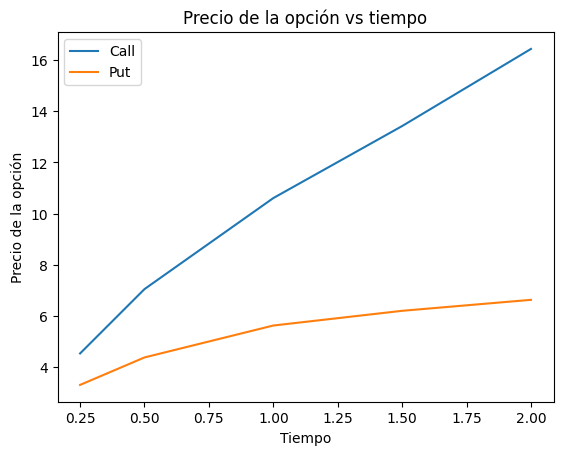

In [20]:
plt.plot(tabla_call["Tiempo"], tabla_call["Precio Call"], label="Call")
plt.plot(tabla_put["Tiempo"], tabla_put["Precio Put"], label="Put")

plt.xlabel("Tiempo")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs tiempo")
plt.legend()

plt.show()

En mis resultados mas tiempo aumenta el valor de las dos opciones porque hay mas oportunidad de que el precio se mueva a favor. Para el comprador puede ser favorable porque tiene mas tiempo para que la opción termine in-the-money.

## RENDIMIENTO

### Put

In [21]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tasas = [0.05, 0.10, 0.15, 0.20]

tabla = []

for r in tasas:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)
    precio_put = np.exp(-r*T)*np.mean(ganancia_put)

    tabla.append([r,precio_put])

tabla = pd.DataFrame(tabla,columns=["Rendimiento","Precio Put"])
tabla_put = tabla

tabla

,Rendimiento,Precio Put
0,0.05,5.659920
1,0.10,3.746718
2,0.15,2.473405
3,0.20,1.527610


### Call

In [22]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tasas = [0.05, 0.10, 0.15, 0.20]

tabla = []

for r in tasas:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_call= np.maximum(ST - K, 0)
    precio_call = np.exp(-r*T)*np.mean(ganancia_call)

    tabla.append([r,precio_call])

tabla = pd.DataFrame(tabla,columns=["Rendimiento","Precio Call"])
tabla_call = tabla

tabla

,Rendimiento,Precio Call
0,0.05,10.513169
1,0.10,13.604966
2,0.15,16.337950
3,0.20,19.692184


### Gráfico

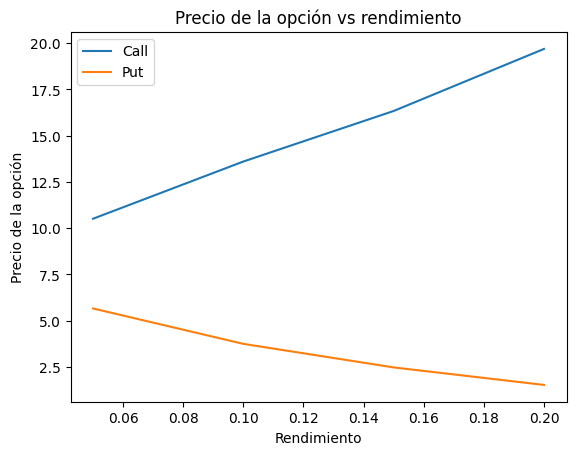

In [23]:
plt.plot(tabla_call["Rendimiento"], tabla_call["Precio Call"], label="Call")
plt.plot(tabla_put["Rendimiento"], tabla_put["Precio Put"], label="Put")

plt.xlabel("Rendimiento")
plt.ylabel("Precio de la opción")
plt.title("Precio de la opción vs rendimiento")
plt.legend()

plt.show()

Cuando aumenta el rendimiento la call aumenta y la put disminuye. Esto pasa porque con una tasa mayor el precio esperado de la acción también es mayor.

# Parte 4. Interpretación

### Precio del activo

La call aumenta cuando aumenta el precio de la acción porque es mas probable que termine arriba de K y genere ganancia. La put se comporta diferente porque necesita que el precio termine abajo de K entonces cuando la acción sube la put pierde valor.

### Volatilidad

Cuando aumenta la volatilidad aumenta el valor de la call y de la put porque hay mas incertidumbre y mas posibilidad de movimientos grandes. Eso puede beneficiar a cualquiera de las dos dependiendo hacia donde se mueva el precio.

### Tiempo

No siempre es deseable tener mas tiempo para todos. En mis resultados tener mas tiempo aumenta el valor de las dos opciones entonces para el comprador es favorable porque tiene mas tiempo para que el precio se mueva y la opción pueda terminar in-the-money. Para el vendedor no es tan favorable porque también hay mas tiempo para que tenga que pagar una ganancia.

### Strike

In-the-money significa que la opción ya tiene valor si se ejerciera. Para una call pasa cuando ST > K y para una put cuando ST < K.

Si aumenta K la call tiene menos probabilidad de terminar in-the-money porque necesita un precio mas alto. En la put pasa lo contrario.

# Parte 4. Comparación con el mercado

Si fuera inversionista yo monitorearía mas la volatilidad porque en mis resultados fue un parámetro que movió bastante el precio de las dos opciones. Cuando la volatilidad subió de 10% a 50% la call pasó de aproximadamente 6.81 a 21.51 y la put de 1.93 a 16.64. Entonces si cambia la incertidumbre del mercado puede cambiar mucho el precio de las opciones.